# TE Flex Analysis — Chunked Pandas Pipeline

Refactored pipeline using **parquet + dask** throughout.
List columns are stored as proper Arrow `LIST<T>` types (no string serialisation),
so all `ast.literal_eval` / `isinstance(x, str)` guards have been removed.

## Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
import xmltodict
import matplotlib.pyplot as plt
import matsim_output_analysis_experienced_te as moa

## Configuration

In [2]:
PLANS = {
    "sp":  "selected plan",
    "ep":  "experienced plan"
}

number_of_unselected_plans = 9
for i in range(1, number_of_unselected_plans+1):
    PLANS.update({f"up{i}": f"unselected plan ({i})"})

FIELDS = [
    "activity_type_or_mode",
    "distance_travelled",
    "duration",
    "location",
    "routes",
    "boardingTime",
]

## Paths & Chunk Settings

`CHUNK` is rows per chunk — start at 20k, watch memory in your task manager, raise it if you have
headroom (bigger chunks = less per-chunk overhead) or lower it if it's tight. Each chunk's output is
written to its own pickle part, so a crash on chunk 14 keeps chunks 0–13 and you can resume.

Pickle (not parquet) is used for the intermediate parts on purpose: the results contain nested
lists-of-lists, which is exactly what makes parquet/Arrow complain. Pickle stores arbitrary Python
objects with no schema inference.

In [18]:
PL_PATH = "1405_2040_10pc_keep10.csv"                       # big plans file (streamed in chunks)
EX_PATH = "0406_2040_10pc_100iters_keep20_experienced.csv"  # experienced file (loaded once)
CHUNK   = 5_000

OUTDIR = Path("chunk_parts")
OUTDIR.mkdir(exist_ok=True)

# dtype hints for the few columns pandas otherwise mis-infers.
# (keys not present in usecols are harmlessly ignored)
pl_dtype = {
    'age': 'float64', 'hholdnumchildren': 'float64', 'hhsize': 'float64',
    'householdid': 'float64', 'individualid': 'float64', 'surveyyear': 'float64',
    'unselected plan (9) number': 'float64',  'unselected plan (10) number': 'float64',
    'unselected plan (11) number': 'float64', 'unselected plan (12) number': 'float64',
    'unselected plan (13) number': 'float64', 'unselected plan (14) number': 'float64',
}

## Load tolls

In [19]:
TOLL_XML_PATH = r"C:\Users\maria\Documents\matsim_analysis\data\2040_dm_keep_history_0.1pc_50plans_5000iters_RP\output_toll.xml\output_toll.xml"
with open(TOLL_XML_PATH, "r", encoding="utf-8") as fh:
    output_tolls = xmltodict.parse(fh.read())
tolls = {item["@id"]: item["cost"]["@amount"] for item in output_tolls["roadpricing"]["links"]["link"]}

## Row-level functions — Strip PT Interaction
*(unchanged from the original)*

In [20]:
def strip_pt_all_fields(row: pd.Series, plan_name: str) -> dict:
    idx = moa.get_ptinteraction_index(row[f"{plan_name} activity_type_or_mode"])
    if not idx:
        return {f"{plan_name} {f}": row[f"{plan_name} {f}"] for f in FIELDS}
    return {f"{plan_name} {f}": moa.remove_ptinteraction(idx, row[f"{plan_name} {f}"]) for f in FIELDS}

# def strip_pt_all_fields(row: pd.Series, plan_name: str) -> dict:
#     types = row[f"{plan_name} activity_type_or_mode"]
#     # if this plan is missing (types is NaN/None/not a list), pass everything through unchanged
#     if not isinstance(types, list):
#         return {f"{plan_name} {f}": row[f"{plan_name} {f}"] for f in FIELDS}

#     idx = moa.get_ptinteraction_index(types)
#     if not idx:
#         return {f"{plan_name} {f}": row[f"{plan_name} {f}"] for f in FIELDS}

#     # PT interactions found — strip them only from fields that are actually lists;
#     # NaN/missing fields pass through and are handled downstream by compute_plan_all's
#     # `isinstance(types, list) and isinstance(routes, list)` check.
#     out = {}
#     for f in FIELDS:
#         v = row[f"{plan_name} {f}"]
#         out[f"{plan_name} {f}"] = moa.remove_ptinteraction(idx, v) if isinstance(v, list) else v
#     return out

def clean_all_plans_per_partition(pdf: pd.DataFrame) -> pd.DataFrame:
    def clean_all(row):
        result = {}
        for plan_name in PLANS.values():
            result.update(strip_pt_all_fields(row, plan_name))
        return result
    cleaned = pdf.apply(clean_all, axis=1, result_type="expand")
    for col in cleaned.columns:
        pdf[col] = cleaned[col]
    del cleaned
    return pdf

## Row-level functions — Structural Features & Utilities
*(unchanged from the original)*

In [21]:
def _missing_plan_result(prefix: str) -> dict:
    return {
        f"{prefix}_legs_indices":                  [],
        f"{prefix}_activities_indices":            [],
        f"{prefix}_leg_durations":                 [],
        f"{prefix}_activity_durations":            [],
        f"{prefix}_activity_starts":               [],
        f"{prefix}_activity_ends":                 [],
        f"{prefix}_stuck_index":                   0,
        f"{prefix}_calculated_activity_durations": [],
        f"{prefix}_activities":                    [],
        f"{prefix}_calculated_activity_u":         [],
        f"{prefix}_calculated_travel_u":           [],
        f"{prefix}_tollvalue":                     float("nan"),
        f"{prefix}_tollcount":                     0,
        f"{prefix}_transfercount":                 0,
        f"{prefix}_calculated_penalty_u":          float("nan"),
        f"{prefix}_total_travel_u":                float("nan"),
        f"{prefix}_total_activity_u":              float("nan"),
        f"{prefix}_calculated_total_u":            float("nan"),
    }


def compute_plan_all(row: pd.Series, plan_name: str, prefix: str, tolls: dict) -> dict:
    types = row[f"{plan_name} activity_type_or_mode"]
    routes = row[f"{plan_name} routes"]
    if not isinstance(types, list) or not isinstance(routes, list):
        return _missing_plan_result(prefix)

    dur = list(row[f"{plan_name} duration"])
    stuck_bool = row["stuck_bool"]

    legs_idx  = moa.get_trips_indices_only(types)
    acts_idx  = moa.get_activities_indices_only(types)
    leg_dur   = moa.get_trips_duration_or_mode(legs_idx, dur)
    act_dur   = moa.get_trips_duration_or_mode(acts_idx, dur)
    act_starts, act_ends, stuck = moa.get_activity_timings(acts_idx, dur, types, stuck_bool)
    calc_act_dur = moa.get_activity_durations(act_starts, act_ends, types, stuck, stuck_bool)
    activities   = moa.get_activities(types, acts_idx, stuck)
    act_u        = moa.calculate_activity_utility(types, acts_idx, stuck, calc_act_dur, stuck_bool)

    travel_series = moa.calculate_travel_utility(
        row["id"], types, dur,
        row[f"{plan_name} distance_travelled"],
        acts_idx, row["subpopulation"],
        row[f"{plan_name} boardingTime"],
        act_ends, routes, tolls, stuck,
    ).to_numpy()
    travel_u = travel_series[0]   # list of Python floats (cast in .py module)
    toll_val = float(travel_series[1])
    toll_cnt = int(travel_series[2])
    xfer_cnt = int(travel_series[3])
    penalty_u = moa.calculate_stuck_penalty(stuck_bool, stuck, types)

    return {
        f"{prefix}_legs_indices":                  legs_idx,
        f"{prefix}_activities_indices":            [int(x) for x in acts_idx],
        f"{prefix}_leg_durations":                 leg_dur,
        f"{prefix}_activity_durations":            act_dur,
        f"{prefix}_activity_starts":               act_starts,
        f"{prefix}_activity_ends":                 act_ends,
        f"{prefix}_stuck_index":                   int(stuck),
        f"{prefix}_calculated_activity_durations": calc_act_dur,
        f"{prefix}_activities":                    activities,
        f"{prefix}_calculated_activity_u":         [float(x) for x in act_u],
        f"{prefix}_calculated_travel_u":           [float(x) for x in travel_u],
        f"{prefix}_tollvalue":                     toll_val,
        f"{prefix}_tollcount":                     toll_cnt,
        f"{prefix}_transfercount":                 xfer_cnt,
        f"{prefix}_calculated_penalty_u":          float(penalty_u),
        f"{prefix}_total_travel_u":                float(sum(travel_u)),
        f"{prefix}_total_activity_u":              float(sum(act_u)),
        f"{prefix}_calculated_total_u":            float(sum(travel_u) + sum(act_u) + penalty_u),
    }


def compute_all_plans_per_partition(pdf: pd.DataFrame, tolls: dict) -> pd.DataFrame:
    pdf = clean_all_plans_per_partition(pdf)  # inline the PT-strip step here

    def compute_all_plans(row):
        result = {}
        for prefix, plan_name in PLANS.items():
            result.update(compute_plan_all(row, plan_name, prefix, tolls))
        return result

    new_features = pd.DataFrame(pdf.apply(compute_all_plans, axis=1).tolist(), index=pdf.index)
    pdf_clean = pdf.loc[:, ~pdf.columns.duplicated()]
    return pd.concat([pdf_clean, new_features], axis=1)

## Row-level functions — Flex Score
*(unchanged from the original)*

In [22]:
import ast
import scipy.stats as sp


def summariseAdjacentLegs(trips):
    return [
        [[item for i, item in enumerate(sublist_j) if i == 0 or item != sublist_j[i-1]]
         for sublist_j in sublist_i]
        for sublist_i in trips
    ]


def trips_to_keep(modes, travel_u, activity_u):
    if not modes:
        return [], [], []
    if not (len(modes) == len(travel_u) == len(activity_u)):
        raise ValueError("All three lists must have the same length")
    if len(modes) == 1:
        return [tuple(modes[0]) if isinstance(modes[0], list) else modes[0]], [travel_u[0]], [activity_u[0]]

    modes_fixed = [tuple(m) if isinstance(m, list) else m for m in modes]
    first_key = modes_fixed[0]
    best = {}
    for idx in range(1, len(modes_fixed)):
        k = modes_fixed[idx]
        if k == first_key:
            continue
        v = travel_u[idx]
        if k not in best or v > best[k][0] or (v == best[k][0] and idx < best[k][1]):
            best[k] = (v, idx)

    chosen = [best[k][1] for k in sorted(best, key=lambda kk: best[kk][1])]
    return (
        [modes_fixed[0]] + [modes_fixed[i] for i in chosen],
        [travel_u[0]]   + [travel_u[i]    for i in chosen],
        [activity_u[0]] + [activity_u[i]  for i in chosen],
    )


def calculate_flex_score(modes, travel_u, activity_u):
    components = []
    k = 2.944
    beta = 0.037
    if isinstance(travel_u, str):
        travel_u = ast.literal_eval(travel_u)
    travel_u = [float(x) for x in travel_u]
    if isinstance(activity_u, str):
        activity_u = ast.literal_eval(activity_u)
    activity_u = [float(x) for x in activity_u]
    modes, travel_u, activity_u = trips_to_keep(modes, travel_u, activity_u)
    for i in range(1, len(modes)):
        try:
            activity_u_ratio = (activity_u[0]-activity_u[i])/activity_u[0]
        except ZeroDivisionError:
            activity_u_ratio = 0
        try:
            travel_u_ratio = (travel_u[0]-travel_u[i])/travel_u[0]
        except ZeroDivisionError:
            travel_u_ratio = 0
        if travel_u_ratio * activity_u_ratio >= 0:
            sigma = -1
        else:
            sigma = 1
        temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))
        components.append(temp)
    if len(components) == 0:
        f = 0
    else:
        f = sp.pmean(components, 2)
    return f


def calculate_flex_score_full(day_modes, day_travel_u, day_activity_u):
    return float(np.mean([
        calculate_flex_score(day_modes[i], day_travel_u[i], day_activity_u[i])
        for i in range(len(day_modes))
    ]))

In [23]:
def compute_flex_calcs_all(row: pd.Series, prefixes: list) -> dict:
    modes_list, travel_u_list, act_u_list = [], [], []
    for prefix in prefixes:
        plan_name = PLANS[prefix]
        modes_list.append(moa.group_legs_into_trips(
            row[f"{plan_name} activity_type_or_mode"],
            row[f"{prefix}_activities_indices"],
            row[f"{prefix}_stuck_index"],
        ))
        travel_u_list.append(row[f"{prefix}_calculated_travel_u"])
        act_u_list.append(row[f"{prefix}_calculated_activity_u"])

    trips_modes        = [list(pair) for pair in zip(*modes_list)]
    travel_utilities   = [list(pair) for pair in zip(*travel_u_list)]
    activity_utilities = [list(pair) for pair in zip(*act_u_list)]

    if any(x is None for x in activity_utilities):
        return {"trips_modes": None, "travel_utilities": None,
                "activity_utilities": None, "trips_modes_summarised": None, "f_score_full": np.nan}

    trips_modes_summarised = summariseAdjacentLegs(trips_modes)
    f_score_full = calculate_flex_score_full(trips_modes_summarised, travel_utilities, activity_utilities)
    return {
        "trips_modes":            trips_modes,
        "travel_utilities":       travel_utilities,
        "activity_utilities":     activity_utilities,
        "trips_modes_summarised": trips_modes_summarised,
        "f_score_full":           f_score_full,
    }


def process_partition(pdf: pd.DataFrame, prefixes: list) -> pd.DataFrame:
    results = pdf.apply(lambda row: compute_flex_calcs_all(row, prefixes), axis=1)
    res_df = pd.DataFrame(results.tolist(), index=pdf.index)
    return pd.concat([pdf, res_df], axis=1)

## Column keep-lists

Same trimming as the old `keep_df3` / `keep_df5`. `df3`-level columns are trimmed **before** the flex
step (the flex functions only need the columns listed here), and `df5`-level columns after.

In [24]:
flex_prefixes = ["sp"] + [k for k in PLANS if k.startswith("up")]

# columns kept after Stage 1 (structural features + utilities)
keep_df3 = (
    ['id', 'subpopulation', 'hzone', 'stuck_bool',
     'selected plan utility',
     'selected plan location',
     'selected plan activity_type_or_mode']
    + ['ep_calculated_total_u']
    + [f'unselected plan ({i}) activity_type_or_mode' for i in range(1, 50)]
    + [f'{p}_{c}' for p in flex_prefixes
                  for c in ['activities_indices', 'stuck_index',
                            'calculated_travel_u', 'calculated_activity_u']]
)

# columns kept after Stage 2 (flex scores) — this is the final df5
keep_df5 = [
    'id', 'subpopulation', 'hzone', 'stuck_bool',
    'selected plan activity_type_or_mode',
    'selected plan location',
    'sp_activities_indices',
    'f_score_full',
    'trips_modes_summarised', 'travel_utilities', 'activity_utilities',
]

## Load the experienced table once + pick plans columns

The experienced file is only 8 columns, so we load it whole and parse its `"; "`-delimited columns
into lists a **single time** (instead of re-parsing every chunk). Each plans-chunk is left-merged
against it.

For the plans file we read only the ~70 columns the pipeline actually touches — a big speed win over
reading all ~500.

In [25]:
def load_experienced(path: str) -> pd.DataFrame:
    # name -> name mapping so column order from the file can't scramble the rename
    rename = {
        "id":                                   "id",
        "selected plan activity_type_or_mode":  "experienced plan activity_type_or_mode",
        "selected plan utility":                "experienced plan utility",
        "selected plan duration":               "experienced plan duration",
        "selected plan distance_travelled":     "experienced plan distance_travelled",
        "selected plan routes":                 "experienced plan routes",
        "selected plan boardingTime":           "experienced plan boardingTime",
        "selected plan location":               "experienced plan location",
    }
    ex = pd.read_csv(path, usecols=list(rename))
    ex = ex.rename(columns=rename)
    # NB: list columns are split later in prepare_chunk (once, on the merged chunk),
    # so nothing is pre-split here.
    return ex


def build_pl_usecols(all_cols) -> list:
    want = ['id', 'subpopulation', 'hzone', 'selected plan utility']
    pl_plans = ['selected plan'] + [f'unselected plan ({i})' for i in range(1, number_of_unselected_plans + 1)]
    for plan in pl_plans:
        for field in FIELDS:
            want.append(f'{plan} {field}')
    return [c for c in want if c in all_cols]

## The chunk processor

One chunk's whole journey: merge → filter → split list columns → `stuck_bool` → Stage 1 features →
trim → Stage 2 flex → trim. Returns the trimmed `df3`-level frame (for the `df4` validation sample)
and the final `df5`-level frame.

The list-splitting guards on `dtype == object`, so the already-parsed experienced columns are skipped
(you can't `.str.split` a column that's already lists).

In [41]:
def process_chunk(chunk_pl: pd.DataFrame, df_ex: pd.DataFrame, tolls: dict):
    # 1. merge against the in-memory experienced table (left == old outer+filters here)
    chunk = chunk_pl.merge(df_ex, on="id", how="left")

    # 2. same filters as the old pipeline (all on plans-side columns)
    chunk = chunk[~chunk["subpopulation"].isin(["hgv", "lgv", "airport", "lgv_ev"])]
    chunk = chunk[chunk["id"].notnull()]
    chunk = chunk[chunk["selected plan routes"].notnull()]
    if len(chunk) == 0:
        return None, None
    chunk = chunk.reset_index(drop=True)

    # 3. split "; "-delimited plans columns into lists (ex columns already split -> skipped by dtype guard)
    for plan_name in PLANS.values():
        for field in FIELDS:
            col = f"{plan_name} {field}"
            # print(col)
            if col in chunk.columns:# and chunk[col].dtype == object:
                # print("here")
                chunk[col] = chunk[col].str.split("; ")

    # print(chunk.iloc[0]["selected plan activity_type_or_mode"])
    print(type(chunk.iloc[0]["selected plan activity_type_or_mode"]))
    # 4. stuck_bool
    def to_str(x):
        try:
            return "; ".join(str(v) for v in x)
        except (TypeError, ValueError):
            return ""
    chunk["stuck_bool"] = (
        chunk["selected plan activity_type_or_mode"].apply(to_str)
        != chunk["experienced plan activity_type_or_mode"].apply(to_str)
    ).astype(int)
    # print(chunk.iloc[0]["stuck_bool"])
    # 5. Stage 1 — structural features + utilities, then trim
    df3c = compute_all_plans_per_partition(chunk, tolls)
    df3c = df3c[[c for c in keep_df3 if c in df3c.columns]]

    # 6. Stage 2 — flex scores, then trim
    df5c = process_partition(df3c, flex_prefixes)
    df5c = df5c[[c for c in keep_df5 if c in df5c.columns]]

    return df3c, df5c

In [43]:
process_chunk(chunk_pl, df_ex, tolls)

<class 'list'>


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


(          id subpopulation      hzone  stuck_bool  selected plan utility  \
 0     108998        ev_low  E02005547           0             220.527128   
 1     108999           low  E02005547           0             201.973542   
 2        109        ev_low  E09000002           0             211.189496   
 3       1090           low  E02004451           0             174.187775   
 4      10900       ev_high  E02005518           0             188.049034   
 ...      ...           ...        ...         ...                    ...   
 4995  113492       ev_high  E09000022           0             126.429739   
 4996  113493       ev_high  E09000026           0             181.529236   
 4997  113494       ev_high  E09000026           0             146.998503   
 4998  113495       ev_high  E09000031           0             186.722374   
 4999  113496       ev_high  E09000031           0             149.181203   
 
                                  selected plan location  \
 0     [651838

## Driver loop

Reads the plans file in chunks, processes each, and writes its outputs to pickle parts. Memory stays
flat because nothing accumulates in RAM during the loop.

If it dies partway, the parts already written survive; re-running skips nothing automatically, so
either clear `chunk_parts/` for a clean run or add a `if (OUTDIR / f"df5_{i:04d}.pkl").exists(): continue`
guard to resume.

In [44]:
df_ex = load_experienced(EX_PATH)
print(f"experienced table loaded: {len(df_ex):,} rows")

all_cols    = pd.read_csv(PL_PATH, nrows=0).columns
pl_usecols  = build_pl_usecols(all_cols)
print(f"reading {len(pl_usecols)} of {len(all_cols)} plans columns")

reader = pd.read_csv(PL_PATH, usecols=pl_usecols, dtype=pl_dtype, chunksize=CHUNK)
for i, chunk_pl in enumerate(reader):
    df3c, df5c = process_chunk(chunk_pl, df_ex, tolls)
    if df5c is None:
        print(f"chunk {i:>4}: empty after filters")
        continue
    df5c.to_pickle(OUTDIR / f"df5_{i:04d}.pkl")
    df3c.sample(frac=0.1).to_pickle(OUTDIR / f"df4_{i:04d}.pkl")  # 10% sample for the utility-check plot
    print(f"chunk {i:>4}: {len(df5c):>6} rows -> written")

print("done.")

experienced table loaded: 488,437 rows
reading 64 of 127 plans columns
<class 'list'>


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


chunk    0:   5000 rows -> written
<class 'list'>


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


chunk    1:   5000 rows -> written
<class 'list'>


...

chunk   95:   5000 rows -> written
<class 'list'>


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


chunk   96:   5000 rows -> written
<class 'list'>


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


chunk   97:   3437 rows -> written
done.


In [45]:
# chunk_pl.iloc[0]["selected plan activity_type_or_mode"]

## Assemble `df5` and `df4`

`df5` is the full flex-score result; `df4` is the 10% `df3`-level sample used by the utility-recreation
plot and the n-unselected sweep. The original `df5 = ...compute()` also pulled the whole thing into
pandas, so holding it in memory here matches the original intent — but if it's too big, work from the
pickle parts directly (e.g. loop over `OUTDIR.glob("df5_*.pkl")` and aggregate).

In [46]:
df5 = pd.concat([pd.read_pickle(p) for p in sorted(OUTDIR.glob("df5_*.pkl"))], ignore_index=True)
df4 = pd.concat([pd.read_pickle(p) for p in sorted(OUTDIR.glob("df4_*.pkl"))], ignore_index=True)
print(f"df5: {len(df5):,} rows   df4 (10% sample): {len(df4):,} rows")

df5: 449,409 rows   df4 (10% sample): 44,941 rows


In [47]:
df4.columns.to_list()

['id',
 'subpopulation',
 'hzone',
 'stuck_bool',
 'selected plan utility',
 'selected plan location',
 'selected plan activity_type_or_mode',
 'ep_calculated_total_u',
 'unselected plan (1) activity_type_or_mode',
 'unselected plan (2) activity_type_or_mode',
 'unselected plan (3) activity_type_or_mode',
 'unselected plan (4) activity_type_or_mode',
 'unselected plan (5) activity_type_or_mode',
 'unselected plan (6) activity_type_or_mode',
 'unselected plan (7) activity_type_or_mode',
 'unselected plan (8) activity_type_or_mode',
 'unselected plan (9) activity_type_or_mode',
 'sp_activities_indices',
 'sp_stuck_index',
 'sp_calculated_travel_u',
 'sp_calculated_activity_u',
 'up1_activities_indices',
 'up1_stuck_index',
 'up1_calculated_travel_u',
 'up1_calculated_activity_u',
 'up2_activities_indices',
 'up2_stuck_index',
 'up2_calculated_travel_u',
 'up2_calculated_activity_u',
 'up3_activities_indices',
 'up3_stuck_index',
 'up3_calculated_travel_u',
 'up3_calculated_activity_u',
 

### Optional: parallelise across cores

The loop above is single-core. Since rows are independent you can fan chunks across cores. **On
Windows, `ProcessPoolExecutor` can't pickle notebook-defined functions** (spawn re-imports `__main__`),
so the clean route is `joblib` with the default `loky` backend, which uses `cloudpickle` and handles
notebook functions. Roughly:

```python
from joblib import Parallel, delayed

def handle(i, chunk_pl):
    df3c, df5c = process_chunk(chunk_pl, df_ex, tolls)
    if df5c is None:
        return
    df5c.to_pickle(OUTDIR / f"df5_{i:04d}.pkl")
    df3c.sample(frac=0.1).to_pickle(OUTDIR / f"df4_{i:04d}.pkl")

reader = pd.read_csv(PL_PATH, usecols=pl_usecols, dtype=pl_dtype, chunksize=CHUNK)
Parallel(n_jobs=6)(delayed(handle)(i, c) for i, c in enumerate(reader))
```

With `n_jobs=6` you hold ~6 chunks + a copy of `df_ex` per worker at once, so size `CHUNK`
accordingly. Get the single-core version running first — a parallel version that crashes is worse
than a serial one that finishes.

## Stage 1.5 — Check utility has been calculated correctly

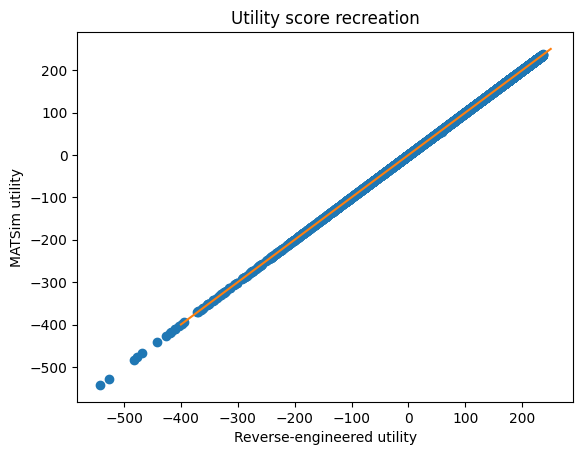

In [51]:
plt.plot(df4["ep_calculated_total_u"], df4["selected plan utility"], "o")
plt.title("Utility score recreation")
plt.xlabel("Reverse-engineered utility")
plt.ylabel("MATSim utility")
x = np.linspace(-400, 250,5)
plt.plot(x,x)

### Plot Flex Histogram

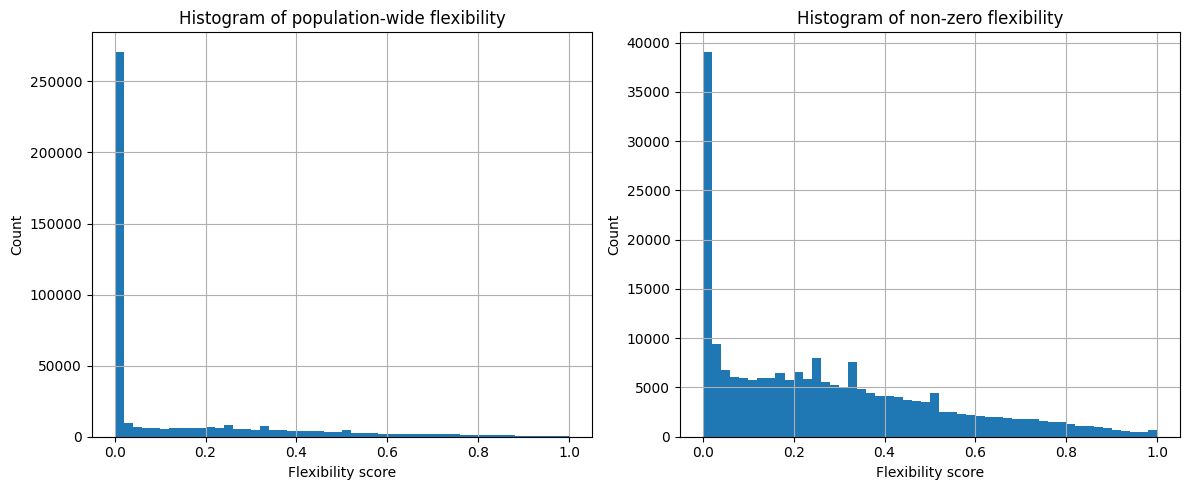

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. First plot (Left side - axes[0])
axes[0].hist(df5["f_score_full"], bins=50)
axes[0].grid(True)
axes[0].set_xlabel("Flexibility score")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of population-wide flexibility")

# 3. Second plot (Right side - axes[1])
axes[1].hist(df5[df5["f_score_full"] > 0]["f_score_full"], bins=50)
axes[1].grid(True)
axes[1].set_xlabel("Flexibility score")
axes[1].set_ylabel("Count")
axes[1].set_title("Histogram of non-zero flexibility")

# 4. Improve spacing so labels don't overlap
plt.tight_layout()
plt.savefig("0506_flex_distribuiton.png")
plt.show()


In [53]:
print(f"the total people is: {len(df5)}")
print(f"the percentage of people with zero scores is: {len(df5[df5["f_score_full"]==0])/len(df5) * 100}")

the total people is: 449409
the percentage of people with zero scores is: 51.60377295514776


### Testing to see how number of unchosen plans affects zero proportion

In [54]:
results = {}
for n in [1, 2, 3, 4, 5, 6,7,8,9]:
    prefixes = ["sp"] + [f"up{i+1}" for i in range(n)]
    result = process_partition(df4, prefixes)   # df4 is already pandas — fast
    total = len(result)
    zeros = (result["f_score_full"] == 0).sum()
    results[n] = zeros / total * 100
    print(f"n_unselected={n:>2}: {results[n]:.2f}% zeros")


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


n_unselected= 1: 84.54% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


n_unselected= 2: 82.30% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


...

n_unselected= 7: 60.67% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


n_unselected= 8: 55.46% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_53744\2943146068.py:64: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


n_unselected= 9: 51.41% zeros


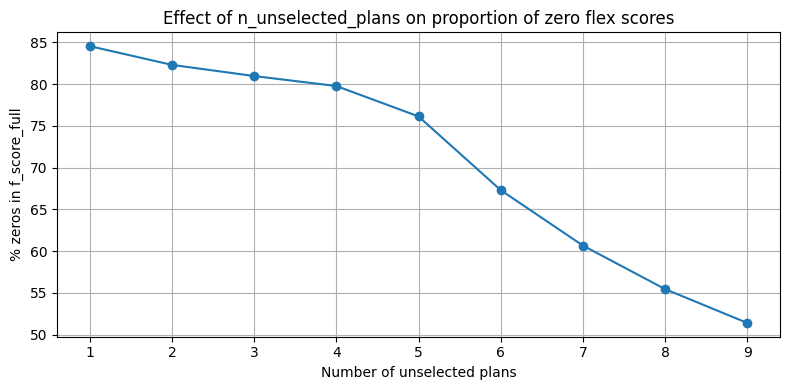

In [55]:
# plot it
plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Number of unselected plans")
plt.ylabel("% zeros in f_score_full")
plt.title("Effect of n_unselected_plans on proportion of zero flex scores")
plt.grid()
plt.tight_layout()
plt.show()

### CD Stats

Now do analysis for abstract on these:
* ~~ get car only stats ~~ 
* drop unnecessary columns
* make density map of flex and CD
* make bivariate map of connectivity / flexibility (aggregate connectivity to MSOA)
* make bivariate map of connectivity / CD (aggregate connectivity to MSOA)
* check I'm calculating flex score correctly (including zeros in average or not??)

In [116]:
def list_of_modes(activity_type_or_mode, activity_indices):
    legs = [val for i, val in enumerate(activity_type_or_mode) if i not in activity_indices]
    return legs
def check_for_modes(modes, target):
    all_tareget_bool = int(all(item == target for item in modes))
    return all_tareget_bool
def check_for_any_car_modes(modes, target_list):
    all_tareget_bool = int(any(item in target_list for item in modes))
    return all_tareget_bool

df5_cd = df5[df5["f_score_full"]==0]
df5_nocd = df5[df5["f_score_full"]>0]

df5_cd["db_trips"] = df5_cd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
df5_nocd["db_trips"] = df5_nocd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
df5_cd["all_car"] = df5_cd.apply(lambda row: check_for_modes(row["db_trips"], "car"), axis=1)
df5_cd["some_car"] = df5_cd.apply(lambda row: check_for_any_car_modes(row["db_trips"], ["car"]), axis=1)

df5_nocd["all_car"] = df5_nocd.apply(lambda row: check_for_modes(row["db_trips"], "car"), axis=1)
df5_nocd["some_car"] = df5_nocd.apply(lambda row: check_for_any_car_modes(row["db_trips"], ["car"]), axis=1)

In [117]:
print(f"The number of zero flexers with all car trips is: {sum(df5_cd["all_car"])} which is {(sum(df5_cd["all_car"])/len(df5_cd))*100}. This is {(sum(df5_cd["all_car"])/len(df5))*100}% of the whole population.")
print(f"The number of zero flexers with some car trips is: {sum(df5_cd["some_car"])} which is {(sum(df5_cd["some_car"])/len(df5_cd))*100}. This is {(sum(df5_cd["some_car"])/len(df5))*100}% of the whole population.")

The number of zero flexers with all car trips is: 112622 which is 48.56238573251923. This is 25.060023275012295% of the whole population.
The number of zero flexers with some car trips is: 137151 which is 59.1392424712822. This is 30.518080412274788% of the whole population.


In [118]:
df5_cd["all_walk"] = df5_cd.apply(lambda row: check_for_modes(row["db_trips"], "walk"), axis=1)
print(f"The number of zero flexers with all walk trips is: {sum(df5_cd["all_walk"])} which is {(sum(df5_cd["all_walk"])/len(df5_cd))*100}. This is {(sum(df5_cd["all_walk"])/len(df5))*100}% of the whole population.")

The number of zero flexers with all walk trips is: 49233 which is 21.22917313463728. This is 10.955054304653444% of the whole population.


### Make maps

In [119]:
import geopandas as gpd
from shapely.geometry import Point
from pyproj import Transformer
import h3

In [120]:
def get_home_index(item_list):
    index = [i for i, val in enumerate(item_list) if val == 'home']
    return index if index else [0] # get the index of where home is if there is a home. if no home, return index 0 (first location)
def get_home_coords(values, indices):
    if not indices:
        return pd.NA
    if not isinstance(values, list) or not isinstance(indices, list):
        raise TypeError("Both values and indices should be lists")

    first_index = indices[0]
    if 0 <= first_index < len(values):
        return values[first_index]
    else:
        return pd.NA
    
def parse_coords(coord_str):
    try:
        if not isinstance(coord_str, str) or ',' not in coord_str:
            return None
        x_str, y_str = coord_str.split(',')
        x, y = float(x_str.strip()), float(y_str.strip())
        return Point(x, y)
    except:
        return None
    
df5["home_index"] = df5['selected plan activity_type_or_mode'].apply(get_home_index)
df5["home_coords"] = df5.apply(lambda row: get_home_coords(row['selected plan location'], row['home_index']), axis=1)
df5[['home_x', 'home_y']] = df5['home_coords'].str.split(',', expand=True).astype(float)
df5['geometry'] = df5['home_coords'].apply(parse_coords)
df5 = df5[df5['geometry'].notnull()].copy()

resolution = 9
transformer = Transformer.from_crs("epsg:27700", "epsg:4326", always_xy=True)
df5["long"], df5["lat"] = transformer.transform(df5['home_x'].values, df5['home_y'].values)
df5['hex_id'] = df5.apply(lambda r: h3.latlng_to_cell(r['lat'], r['long'], resolution), axis=1)

gdf = gpd.GeoDataFrame(df5, geometry='geometry', crs="EPSG:27700")  
gdf_nonzero = gpd.GeoDataFrame(df5, geometry='geometry', crs="EPSG:27700")  

In [121]:
def list_of_modes(activity_type_or_mode, activity_indices):
    legs = [val for i, val in enumerate(activity_type_or_mode) if i not in activity_indices]
    return legs
def check_for_modes(modes, target):
    all_tareget_bool = int(all(item == target for item in modes))
    return all_tareget_bool
def check_for_any_car_modes(modes, target_list):
    all_tareget_bool = int(any(item in target_list for item in modes))
    return all_tareget_bool

gdf_cd = gdf[gdf["f_score_full"]==0]
gdf_nocd = gdf[gdf["f_score_full"]>0]

gdf_cd["db_trips"] = gdf_cd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
gdf_nocd["db_trips"] = gdf_nocd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
gdf_cd["all_car"] = gdf_cd.apply(lambda row: check_for_modes(row["db_trips"], "car"), axis=1)
gdf_cd["some_car"] = gdf_cd.apply(lambda row: check_for_any_car_modes(row["db_trips"], ["car"]), axis=1)

gdf_nocd["all_car"] = gdf_nocd.apply(lambda row: check_for_modes(row["db_trips"], "car"), axis=1)
gdf_nocd["some_car"] = gdf_nocd.apply(lambda row: check_for_any_car_modes(row["db_trips"], ["car"]), axis=1)

In [122]:
msoas = gpd.read_file(r"C:\Users\maria\Documents\matsim_analysis\data\MSOA_2021_EW\MSOA_2021_EW_BSC_V3.shp")
msoa_lsoa_lookup = pd.read_csv(r"C:\Users\maria\OneDrive - University College London\Documents\Data\DfT\PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU\PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU.csv")
connectivity = pd.read_csv(r"C:\Users\maria\OneDrive - University College London\Documents\Data\DfT\connectivity_metrics_2025_LSOA.csv", skiprows=2)

C:\Users\maria\AppData\Local\Temp\ipykernel_53744\1970511617.py:2: DtypeWarning: Columns (0: ladnmw) have mixed types. Specify dtype option on import or set low_memory=False.
  msoa_lsoa_lookup = pd.read_csv(r"C:\Users\maria\OneDrive - University College London\Documents\Data\DfT\PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU\PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU.csv")


In [123]:
gdf = gpd.sjoin(gdf, msoas, how="left", predicate="within")
gdf_nonzero = gdf[gdf["f_score_full"]>0]

In [134]:
gdf_nocd = gpd.sjoin(gdf_nocd, msoas, how="left", predicate="within")

In [124]:
msoa_stats = gdf.groupby('MSOA21CD')['f_score_full'].agg(
    f_score_mean='mean',
    f_score_median='median',
    count='count',
).reset_index()

mean_flex   = msoa_stats[['MSOA21CD', 'count', 'f_score_mean']].rename(columns={'f_score_mean': 'f_score_full'})
median_flex = msoa_stats[['MSOA21CD', 'count', 'f_score_median']].rename(columns={'f_score_median': 'f_score_full'})

msoa_mean   = msoas.merge(msoa_stats, on='MSOA21CD', how='left')
msoa_median = msoas.merge(msoa_stats[['MSOA21CD', 'f_score_median', 'count']], on='MSOA21CD', how='left')

xmin, ymin, xmax, ymax = gdf.total_bounds

In [125]:
len(msoa_mean)

7264

In [126]:
msoa_mean = msoa_mean[msoa_mean["count"]>10]
len(msoa_mean)

1536

In [127]:
# mean_flex_nonzero = gdf_nonzero.groupby('MSOA21CD')['f_score_full'].mean().reset_index()
# median_flex_nonzero = gdf_nonzero.groupby('MSOA21CD')['f_score_full'].median().reset_index()

# # 6. Merge the median values back to the MSOA map
# msoa_mean_nonzero = msoas.merge(mean_flex_nonzero, on='MSOA21CD', how='left')
# msoa_median_nonzero = msoas.merge(median_flex_nonzero, on='MSOA21CD', how='left')

# xmin_nonzero, ymin_nonzero, xmax_nonzero, ymax_nonzero = gdf_nonzero.total_bounds

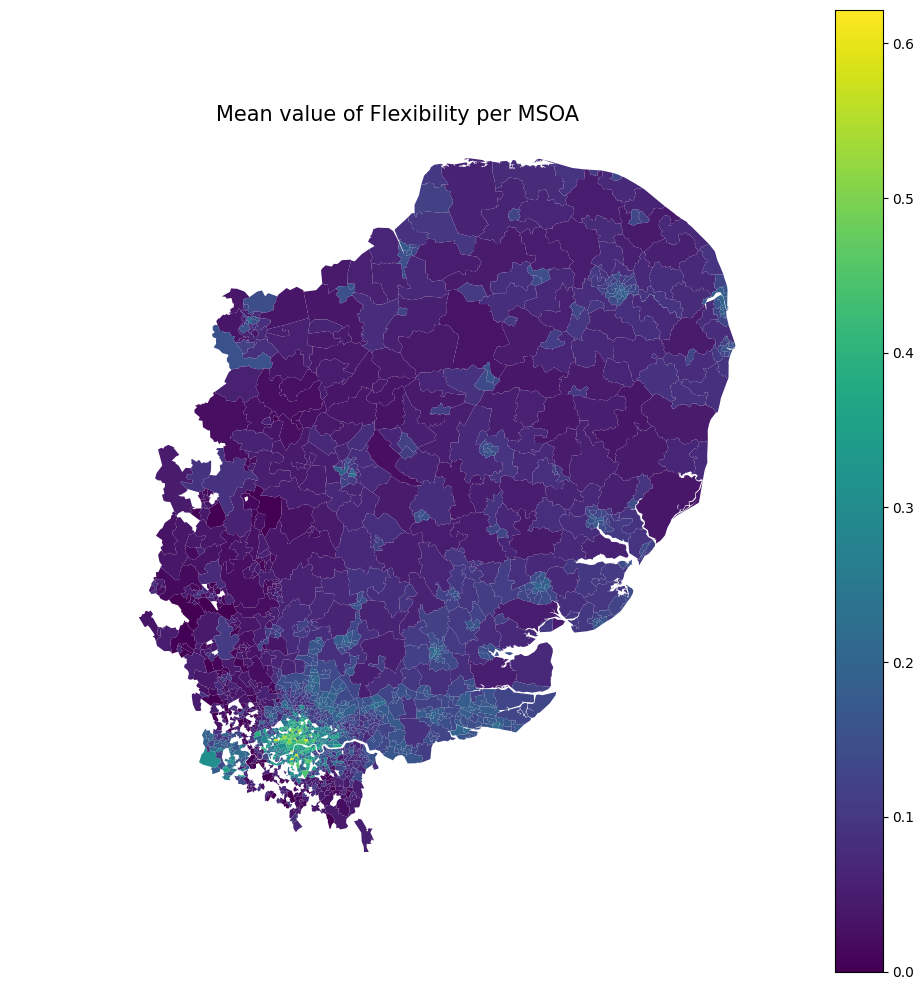

In [128]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset


fig, ax1 = plt.subplots( figsize=(10, 10))

# --- MAP 1: MEAN ---
msoa_mean.plot(column='f_score_mean', ax=ax1, legend=True, cmap='viridis',
               missing_kwds={'color': 'lightgrey'})
ax1.set_title('Mean value of Flexibility per MSOA', fontsize=15)
ax1.axis('off')

ax1.set_xlim(450000, 670000)
ax1.set_ylim(150000, 355000)


plt.tight_layout()
plt.savefig("0506_flex_msoa_density.png")
plt.show()


In [129]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# # 1. Create the 1x2 figure
# fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(20, 10))
# # fig, ax1 = plt.subplots(1, 1, figsize=(10, 10))

# # Define your zoom area (adjust these to your specific Eastings/Northings)
# z_xmin, z_xmax = 500000, 550000 
# z_ymin, z_ymax = 160000, 195000

# # --- MAP 1: MEAN ---
# msoa_mean_nonzero.plot(column='f_score_full', ax=ax1, legend=True, cmap='viridis',
#                missing_kwds={'color': 'lightgrey'})
# ax1.set_title('Mean Value of non-zero Flex Score', fontsize=15)
# ax1.axis('off')
# ax1.set_xlim(450000, 670000)
# ax1.set_ylim(150000, 355000)

# # --- MAP 2: MEAN ---
# msoa_mean.plot(column='f_score_full', ax=ax2, legend=True, cmap='viridis',
#                missing_kwds={'color': 'lightgrey'})
# ax2.set_title('Mean Value of Flex Score', fontsize=15)
# ax2.axis('off')
# # ax1.set_xlim(xmin, xmax)
# # ax1.set_ylim(ymin, ymax)
# ax2.set_xlim(450000, 670000)
# ax2.set_ylim(150000, 355000)

# plt.tight_layout()
# # plt.savefig("mean_flex_score_MSOA_both.png")
# plt.show()


In [130]:
msoa_lsoa_lookup.columns = msoa_lsoa_lookup.columns.str.upper()

In [131]:
connectivity = connectivity.merge(msoa_lsoa_lookup[["LSOA21CD", "MSOA21CD"]], on="LSOA21CD", how="left")
msoa_connectivity = connectivity.groupby("MSOA21CD")["Overall"].mean().reset_index()

In [132]:
msoa_biv = msoa_mean.merge(msoa_connectivity, left_on="MSOA21CD", right_on="MSOA21CD", how="left")

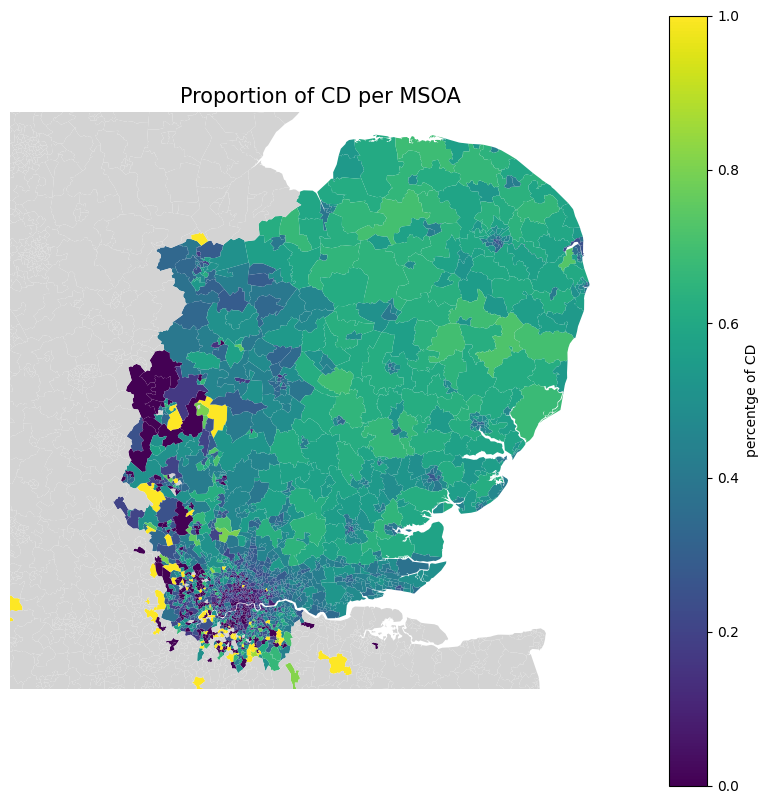

In [135]:
some_car = gdf_nocd.groupby('MSOA21CD')['some_car'].mean().reset_index()
all_car = gdf_nocd.groupby('MSOA21CD')['all_car'].mean().reset_index()

# 6. Merge the median values back to the MSOA map
msoa_map = msoas.merge(all_car, on='MSOA21CD', how='left')

xmin, ymin, xmax, ymax = gdf_nocd.total_bounds

# 7. Plot the Map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
msoa_map.plot(
    column='all_car', 
    ax=ax, 
    legend=True, 
    cmap='viridis',
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
    legend_kwds={'label': "percentge of CD"}
)

ax.set_title('Proportion of CD per MSOA', fontsize=15)
ax.axis('off')
ax.set_xlim(450000, 670000)
ax.set_ylim(150000, 355000)
plt.savefig("0506_cd_msoa_density.png")
plt.show()

In [136]:
import pandas as pd
import geopandas as gpd
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

In [138]:
msoa_biv_over0 = msoa_biv[msoa_biv["f_score_mean"]>0]

(-10.0, 0.0)

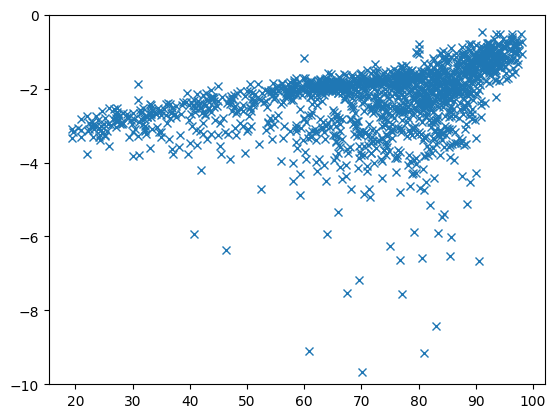

In [139]:
plt.plot(msoa_biv_over0["Overall"], np.log(msoa_biv_over0["f_score_mean"]), 'x')
plt.ylim([-10, 0])

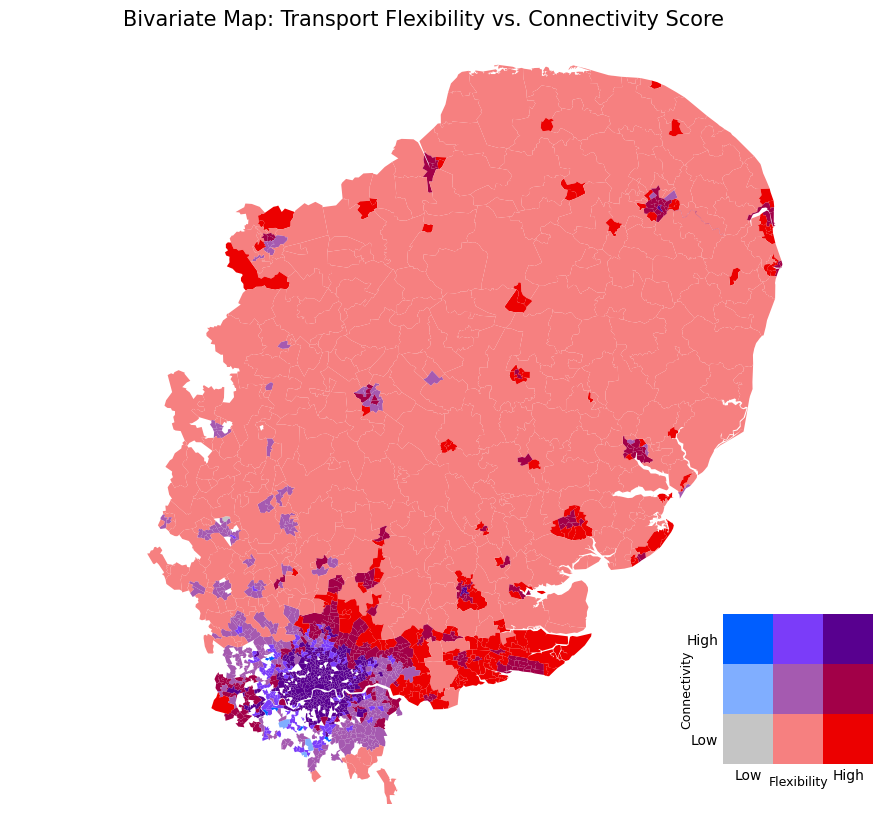

In [140]:
# Classify into 3 quantile bins each
# flex_bins = [0, 0.5, 1.0]
# mq_flex = mapclassify.UserDefined(msoa_biv['f_score_full'], bins=flex_bins)

nonzero = msoa_biv['f_score_mean'].dropna()
nonzero = nonzero[nonzero > 0]
midpoint = nonzero.quantile(0.5)   # 50th percentile of non-zeros

flex_bins = [0, midpoint, nonzero.max()]
mq_flex = mapclassify.UserDefined(msoa_biv['f_score_mean'], bins=flex_bins)

# mq_flex = mapclassify.Quantiles(msoa_biv["f_score_full"], k=3)
mq_conn = mapclassify.Quantiles(msoa_biv["Overall"], k=3)
msoa_biv["flex_q"] = mq_flex.yb
msoa_biv["conn_q"] = mq_conn.yb
msoa_biv["bi_class"] = msoa_biv["flex_q"] + (msoa_biv["conn_q"] * 3)

# Bivariate colour palette (3x3): rows = connectivity (low→high), cols = flexibility (low→high)
bivariate_colors = [
    "#c5c5c5", "#f68080", "#ec0000",
    "#80aeff", "#a55ab0", "#a20048",
    "#005eff", "#7b3cf9", "#58008f",
]

fig, ax = plt.subplots(figsize=(12, 10))
msoa_biv.plot(column="bi_class", cmap=ListedColormap(bivariate_colors), ax=ax, linewidth=0.1)
ax.set_title("Bivariate Map: Transport Flexibility vs. Connectivity Score", fontsize=15)
ax.axis("off")

# Legend
ax_legend = fig.add_axes([0.75, 0.15, 0.15, 0.15])
for i in range(3):
    for j in range(3):
        rect = patches.Rectangle((j, i), 1, 1, linewidth=0, facecolor=bivariate_colors[j + i * 3])
        ax_legend.add_patch(rect)
ax_legend.set_xlim(0, 3); ax_legend.set_ylim(0, 3)
ax_legend.set_xticks([0.5, 2.5]); ax_legend.set_xticklabels(["Low", "High"], fontsize=10)
ax_legend.set_yticks([0.5, 2.5]); ax_legend.set_yticklabels(["Low", "High"], fontsize=10)
ax_legend.set_xlabel("Flexibility", fontsize=9, labelpad=-5)
ax_legend.set_ylabel("Connectivity", fontsize=9, labelpad=-5)
ax_legend.tick_params(length=0)
ax.set_xlim(450000, 670000)
ax.set_ylim(150000, 355000)
for spine in ax_legend.spines.values(): spine.set_visible(False)
ax_legend.set_aspect("equal")

plt.savefig("0506_connectivity_flex_bivariate.png")
plt.show()